# CLO DUAL JSON MAKER_V2

In [1]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from glob import glob
import math
from pprint import pprint
import torch

import pygarment as pyg
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

from tqdm import tqdm
import json
import random

import trimesh
from ANALYSIS.analysis_utils import (
    plot_panel_info,
    visualize_meshes_plotly,
    v_id_map
)

In [53]:
# TODO 좌표 변환한 상태로 TEST
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
"Arm_Mid_1_L" :  [ 20.4240,  138.30371, -1.300],
"Arm_Mid_2_L" :  [ 25.4240,  133.80371, -1.000],
"Arm_Mid_3_L" :  [ 30.4240,  129.30371, -0.7000],
"Arm_Mid_4_L" :  [ 35.4240,  124.80371, -0.4000],
"Arm_Mid_5_L" :  [ 40.4240,  120.30371, -0.1000],
"Arm_Mid_6_L" :  [ 45.4240,  115.80371,  0.2000],
"Arm_Mid_7_L" :  [ 50.4240,  111.30371,  0.5000],
"Arm_Mid_8_L" :  [ 55.4240,  106.80371,  0.8000],
"Arm_Mid_1_R" : [ -20.4240,  138.30371, -1.300],
"Arm_Mid_2_R" : [ -25.4240,  133.80371, -1.000],
"Arm_Mid_3_R" : [ -30.4240,  129.30371, -0.7000],
"Arm_Mid_4_R" : [ -35.4240,  124.80371, -0.4000],
"Arm_Mid_5_R" : [ -40.4240,  120.30371, -0.1000],
"Arm_Mid_6_R" : [ -45.4240,  115.80371,  0.2000],
"Arm_Mid_7_R" : [ -50.4240,  111.30371,  0.5000],
"Arm_Mid_8_R" : [ -55.4240,  106.80371,  0.8000],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_7_R" : [ -11.86359, 100.30371,   15.25501],
"Body_Front_8_R" : [ -11.86359,  93.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_7_L" : [ 11.86359, 100.30371,   15.25501],
"Body_Front_8_L" : [ 11.86359,  93.30371,   15.25501],
"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_7_R" :[ -11.86359, 100.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_7_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
#TODO: 얘 보다는 skirt_front_mid가 좋음"Leg_Front_Mid_2" :[0, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
#TODO: 얘 보다는 skirt_back_mid가 좋음"Leg_Back_Mid_2" :[0, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center" : [0, 54.30371, 15.25501],#[0, 56.30371, 15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],#[0, 56.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
"Head_L" : [ 10., 160.30371, 0],
"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_Top_L" :[ 5., 172.30371, 0],
"Head_Top_R" :[ -5., 172.30371, 0],
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}
# Neck, shoulder는 일단 보류
# add y-axis -10 해야 아구가 맞음
for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]

In [10]:
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
# Mid 일단 안씀.
# "Arm_Mid_1_L" :  [ 20.4240,  138.30371, -1.300],
# "Arm_Mid_2_L" :  [ 25.4240,  133.80371, -1.000],
# "Arm_Mid_3_L" :  [ 30.4240,  129.30371, -0.7000],
# "Arm_Mid_4_L" :  [ 35.4240,  124.80371, -0.4000],
# "Arm_Mid_5_L" :  [ 40.4240,  120.30371, -0.1000],
# "Arm_Mid_6_L" :  [ 45.4240,  115.80371,  0.2000],
# "Arm_Mid_7_L" :  [ 50.4240,  111.30371,  0.5000],
# "Arm_Mid_8_L" :  [ 55.4240,  106.80371,  0.8000],
# "Arm_Mid_1_R" : [ -20.4240,  138.30371, -1.300],
# "Arm_Mid_2_R" : [ -25.4240,  133.80371, -1.000],
# "Arm_Mid_3_R" : [ -30.4240,  129.30371, -0.7000],
# "Arm_Mid_4_R" : [ -35.4240,  124.80371, -0.4000],
# "Arm_Mid_5_R" : [ -40.4240,  120.30371, -0.1000],
# "Arm_Mid_6_R" : [ -45.4240,  115.80371,  0.2000],
# "Arm_Mid_7_R" : [ -50.4240,  111.30371,  0.5000],
# "Arm_Mid_8_R" : [ -55.4240,  106.80371,  0.8000],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_7_R" : [ -11.86359, 100.30371,   15.25501],
"Body_Front_8_R" : [ -11.86359,  93.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_7_L" : [ 11.86359, 100.30371,   15.25501],
"Body_Front_8_L" : [ 11.86359,  93.30371,   15.25501],
"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_7_R" :[ -11.86359, 100.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_7_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
#TODO: 얘 보다는 skirt_front_mid가 좋음"Leg_Front_Mid_2" :[0, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
#TODO: 얘 보다는 skirt_back_mid가 좋음"Leg_Back_Mid_2" :[0, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center" : [0, 54.30371, 15.25501],#[0, 56.30371, 15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Front_Center_4":[0, 30.30371, 15.25501],
"Skirt_Front_Center_5":[0, 18.30371, 15.25501],
"Skirt_Front_Center_6" : [0, 6.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],#[0, 56.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Skirt_Back_Center_4" :[0, 30.30371, -15.25501],
"Skirt_Back_Center_5" :[0, 18.30371, -15.25501],
"Skirt_Back_Center_6" :[0, 6.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
"Head_L" : [ 10., 160.30371, 0],
"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_Top_L" :[ 5., 172.30371, 0],
"Head_Top_R" :[ -5., 172.30371, 0],
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}
for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]

In [11]:
# 필요한 함수 실행
import pandas as pd
from svgpathtools import Path, Line, QuadraticBezier, CubicBezier, Arc
import os
import random
import string
import json
def euler_angles_to_rotation_matrix(euler_angles):
    """
    Convert Euler angles to a rotation matrix.
    
    Parameters:
    euler_angles (tuple or list): A tuple or list of three angles (roll, pitch, yaw) in radians.
    
    Returns:
    np.ndarray: A 3x3 rotation matrix.
    """
    roll, pitch, yaw = euler_angles

    # Compute individual rotation matrices
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)]
    ])

    R_y = np.array([
        [np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])

    R_z = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw), np.cos(yaw), 0],
        [0, 0, 1]
    ])

    # Combine the rotation matrices
    R = np.dot(R_z, np.dot(R_y, R_x))

    return R

def calculate_center_point(panel_name, spec, panel_svg_path_dict):
    vertices_from_spec = np.asarray(spec['pattern']['panels'][panel_name]['vertices'])    
    offset = np.min(vertices_from_spec * np.array([1, -1]), axis=0)

    euler_angles = spec['pattern']['panels'][panel_name]['rotation']
    translation = spec['pattern']['panels'][panel_name]['translation']
    rotation_matrix = euler_angles_to_rotation_matrix(euler_angles)

    path = panel_svg_path_dict[panel_name][0]
    
    x1, x2, y1, y2 = path.bbox()
    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2 
    
    bbox_center = np.array([xm, ym])
    bbox_center = (bbox_center + offset) * np.array([1, -1])
    
    batch_point = np.array([
        bbox_center[0], bbox_center[1], 1
    ]) @ rotation_matrix.T + translation
    #print(panel_name, batch_point) 
    return batch_point.reshape(1, -1)
    # batch_point_list.append(batch_point.reshape(1, -1))

def matching_point(target_point):
# 모든 batch_point들과 target_point 간의 거리(L2 norm) 계산
    keys = list(batch_points.keys())  # batch_point의 key 목록
    values = np.array(list(batch_points.values()))  # value를 numpy 배열로 변환

    # L2 거리 계산 (유클리드 거리)
    distances = np.linalg.norm(values - target_point, axis=1)

    # 가장 가까운 key 찾기
    closest_index = np.argmin(distances)  # 최소 거리의 인덱스
    closest_key = keys[closest_index]  # 해당 인덱스의 key 가져오기

    #print(f"가장 가까운 batch_point: {closest_key}")
    
    return closest_key    



def process_path_data(data):
    """
    주어진 Path 데이터를 DataFrame으로 처리.
    - 요소 타입 변환 (QuadraticBezier -> Bezier Curve, Line -> Straight)
    - start, control, control1, control2, end, radius의 실수부/허수부를 x, y로 분리
    - 복소수 열 제거
    
    Args
        data (tuple): Path 객체와 속성 정보가 포함된 데이터
    
    Returns:
        pd.DataFrame: 처리된 데이터프레임
    """
    rows = []
    # Path 내부 요소 순회
    for element in data[0]:
        row = {
            "type": type(element).__name__,  # 요소 타입
            "start": getattr(element, "start", None),
            "controla": getattr(element, "control", None),
            "controlb": getattr(element, "control", None),
            "control1": getattr(element, "control1", None),
            "control2": getattr(element, "control2", None),
            "end": getattr(element, "end", None),
            "radius": getattr(element, "radius", None),
            "rotation": getattr(element, "rotation", None),
            "large_arc": getattr(element, "large_arc", None),
            "sweep": getattr(element, "sweep", None),
        }
        rows.append(row)
    
    # DataFrame 생성
    df = pd.DataFrame(rows)
    
    # type 열의 값을 변경하기 위한 매핑 사전
    type_mapping = {
        "QuadraticBezier": "Bezier Curve",
        "CubicBezier": "Bezier Curve",
        "Line": "Straight",
        "Arc": "Arc", #임의로 바꿈    
    }
    
    # type 열 값 변경
    df["type"] = df["type"].map(type_mapping).fillna(df["type"])
    
    # TODO: 2024.01.16 이후 Arc에 대한 정보에 대해 Bezier Curve로 변환예정.
    # -> 일단 되게 끔 하는게 목표.
    # 대상 열 목록
    coordinate_columns = ["start",  "controla", "controlb", "control1", "control2",  "end"] 
    
    # 실수부와 허수부를 분리하여 새로운 열로 추가하는 함수
    def extract_coordinates(df, columns):
        for col in columns:
            df[f"{col}_x"] = df[col].apply(lambda z: z.real if isinstance(z, complex) else None)
            df[f"{col}_y"] = df[col].apply(lambda z: z.imag if isinstance(z, complex) else None)
        # TODO: x, y 좌표를 상하 반전
        # minimize
        max_y = df[['start_y', 'controla_y', 'controlb_y', 'control1_y', 'control2_y', 'end_y']].max().max()
        min_y = df[['start_y', 'controla_y', 'controlb_y', 'control1_y', 'control2_y', 'end_y']].min().min()
        stand_y = (max_y + min_y)

        for col in columns: 
            df[f"{col}_y"] = (stand_y - df[f"{col}_y"]) * (8.5) #TODO: 01.17 scaling까지 
            df[f"{col}_x"] = df[f"{col}_x"]* (8.5)#TODO: scaling까지 
        df['controlb_x'] = df['controla_x'].round(4) # TODO: ontrolb_x 에 round
        # TODO: 여기까지
        return df
    
    # 실수부와 허수부를 분리하여 데이터프레임에 추가
    df = extract_coordinates(df, coordinate_columns)
    
    # 기존 열 중 복소수 값을 제거
    df = df.drop(columns=coordinate_columns)
    
    return df
# 2번
# 각 panel에 대한 start, end 좌표를 저장해 놓는 함수
# TODO: 2024.01.19 15:29 name 추가함.

def calculate_edge_length(edge):
    """
    각 엣지의 길이를 계산. QuadraticBezier의 경우 CubicBezier처럼 처리.
    """
    if isinstance(edge, Line):
        return abs(edge.end - edge.start)
    elif isinstance(edge, QuadraticBezier):
        # QuadraticBezier -> CubicBezier 변환
        # 기존 컨트롤 포인트
        control1 = edge.control
        
        # 새로운 컨트롤 포인트 추가
        control2 = complex(round(control1.real, 4), control1.imag)  # x좌표 소수점 4자리로 변경
        # QuadraticBezier -> CubicBezier 변환
        cubic_edge = CubicBezier(
            start=edge.start,
            control1=control1,
            control2=control2,
            end=edge.end
        )
        # CubicBezier 길이 계산
        return cubic_edge.length()
    elif isinstance(edge, CubicBezier):
        return edge.length()
    elif isinstance(edge, Arc):
        return edge.length()
    else:
        raise ValueError(f"Unsupported edge type: {type(edge)}")

def calculate_fstart_fend(path, panel_name):
    """
    전체 엣지에 대해 fstart와 fend를 계산.
    """
    total_length = sum(calculate_edge_length(edge) for edge in path)
    fstart = 0.0
    results = []

    for idx, edge in enumerate(path):  # enumerate를 사용하여 번호 부여
        edge_length = calculate_edge_length(edge) # TODO: name 넣어봄 01.19.17:00
        fend = fstart + (edge_length / total_length)
        results.append({
            "edge_id": idx,  # 엣지 번호
            "edge": str(edge),  # Edge를 문자열로 변환하여 저장
            "fstart": round(fstart, 6),
            "fend": round(fend, 6)
        })
        fstart = fend

    return results

# 패널 이름에 따라 데이터프레임 처리
def process_negative_columns(panel_names, panel_dataframes):
    # 패널 이름이 '_back', '_b', '_btorso'로 끝나는 경우
    if '_back' in panel_names or '_b' in panel_names or '_btorso' in panel_names or "_b_l" in panel_names or "_b_r" in panel_names:
        #print(f"Processing panel: {panel_names}")  # 디버깅 출력
        # 해당 데이터프레임의 '_x'로 끝나는 열 처리
        df = panel_dataframes
        df_columns = df.columns  # 데이터프레임 열 이름 가져오기

        # TODO: 20240123 15:30 그냥 해봄            
        for col in df_columns:
            if col.endswith('_x'):  # '_x'로 끝나는 열 확인
                # df[col] = stand_x - df[col]
                df[col] = df[col] * -1  # 열 값에 음수 곱하기
    else:
        #print(f"Skipping panel: {panel_names}")
        pass
    return panel_dataframes

def convert_stitch_dict(stitch_dict, panel_index_mapping):
    new_stitch_dict = {}
    for key, value in stitch_dict.items():
        new_stitch_dict[key] = [
            {'panel': panel_index_mapping[stitch['panel']], 'edge': stitch['edge']} for stitch in value
        ]
    value_stack = []
    for value in new_stitch_dict.values():
        # dictionary stack
        for value in value:
            value_stack.append(value)
              
    return value_stack

# 통합할때 추가하는 방법. (2024.02.04 작성)
def unify_clo_json_data(Clo_json_path, Clo_json_path_to_add):
    with open(Clo_json_path, 'r') as file:
        json_data = json.load(file)
    with open(Clo_json_path_to_add, 'r') as file:
        json_data_to_add = json.load(file)
    
    # FabricList, GradingRuleTableList(제껴도됨), PatternList, SymmetricDataList(제껴도됨), InstanceDataList, SeamLinePairGroupList
    # 통합할때 추가하는 방법.
    # Fabric의 경우
    json_data['FabricList'].append(json_data_to_add['FabricList'][0])
    # Pattern의 경우
    [json_data['PatternList'].append(json_data_to_add['PatternList'][num]) for num in range(len(json_data_to_add['PatternList']))]
    # InstanceDataList의 경우
    [json_data['InstanceDataList'].append(json_data_to_add['InstanceDataList'][num]) for num in range(len(json_data_to_add['InstanceDataList']))]
    # SeamLinePairGroupList의 경우
    [json_data['SeamLinePairGroupList'].append(json_data_to_add['SeamLinePairGroupList'][num]) for num in range(len(json_data_to_add['SeamLinePairGroupList']))]
    
    return json_data
# 통합된 STITCH 추가하는 방법. (2024.02.04 작성)
def stitch_data_unify(Clo_stitch_path, Clo_stitch_path_to_add):
    with open(Clo_stitch_path, "r") as f:
        stitch_data_1 = json.load(f)
    #stitch_data_1
    with open(Clo_stitch_path_to_add, "r") as f:
        stitch_data_2 = json.load(f)
    
    max_panel_1 = max(d["panel"] for d in stitch_data_1)
    offset = max_panel_1 + 1
    for item in stitch_data_2:
        item["panel"] += offset
    return stitch_data_1+stitch_data_2

# Unique UUID 생성
def get_unique_random_string(existing_set):
    
    while True:
        # 영문(대소문자) + 숫자
        candidate = ''.join(random.choices(string.ascii_letters + string.digits, k=6))
        # 중복 검사
        if candidate not in existing_set:
            existing_set.add(candidate)
            return candidate
    

In [12]:
json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

json_data = load_json_file(json_file_path)
len(json_data)

30427

In [13]:
# 루트 돌게끔.
# 여러 패널의 정보를 저장할 딕셔너리
import os
import json
from tqdm import tqdm
#garment_id = os.path.basename(SPEC_FILE_PATH)

# NO_ARC_PATH
json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

json_data = load_json_file(json_file_path)
#IDX = random.randint(0, len(json_data) - 1)
# random Fabric UUID 생성을 위해 유니크하게.
generated = set()

for IDX in tqdm(range(len(json_data))):
    # random Fabric UUID 생성
    fabric_uuid = get_unique_random_string(generated)    
    # radnom hexa code 생성
    random_hexa_code = ''.join(random.choices('0123456789ABCDEF', k=6))
    garment_path = json_data[IDX]
    path_split= garment_path.split(os.sep)
    garment_id= os.path.basename(garment_path)
    SPEC_FILE_PATH = os.path.join(garment_path,  f"{garment_id}_specification.json")

    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

    drawn_pattern_list = list(map(
        lambda pannel_name : pattern._draw_a_panel(
            pannel_name, apply_transform=False, fill=True
        ),
        pattern.panel_order()
    ))

    panel_svg_path_dict = {
        panel_name : pattern._draw_a_panel(
            panel_name, apply_transform=False, fill=True
        )
        for panel_name in pattern.panel_order()
    }

    stitch_dict = {
        i : v for i, v in enumerate(pattern.pattern['stitches'])
    }

    # json의 rotation translation 추출을 위한 정보
    spec = load_json_file(SPEC_FILE_PATH)


    panel_fstart_fend_info = {}

    # 패널 리스트 (예: pattern.panel_order())
    panel_list = pattern.panel_order()

    # 각 패널에 대해 fstart, fend 계산
    for panel_name in panel_list:
        path = panel_svg_path_dict[panel_name][0]  # 패널에 해당하는 경로 정보 가져오기
        fstart_fend_results = calculate_fstart_fend(path, panel_name) # TODO: 2024.01.19 14:33 panel_name 넣기
        panel_fstart_fend_info[panel_name] = fstart_fend_results  # 결과를 딕셔너리에 저장

    # 패널 데이터프레임 생성
    panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
    panel_names = list(pattern.panel_order())


    # Initialize the top-level JSON structure
    garment_data = {
        "FabricList": [],
        "GradingRuleTableList": [],
        "PatternList": [],
        "SymmetricDataList": [],
        "InstanceDataList": [],
        "SeamLinePairGroupList": [],
    }

    # Process each panel
    for panel_name, df in zip(panel_names, panel_dataframes):
        # Initialize JSON structure for the panel
        panel_dataframes = process_negative_columns(panel_name, df)
        panel_center_point = calculate_center_point(panel_name, spec, panel_svg_path_dict)
        #print(f"{panel_name} 의 중심점 좌표 : {panel_center_point}")
        panel_batch_point = matching_point(panel_center_point) # batch point 이름 받기
        panel_data = {
            "Name": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "fGrainlineAngle": 0.0,
            "ID": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "strSuperImposeSide": "None",
            "CurrentFabricUUID": fabric_uuid,
            "IsClosed": False,
            "InternalLineList": [],
            "ButtonHeadList": [],
            "ButtonHoleList": [],
            "AnnotationList": [],
            "NotchList": [],
            "IsHalfSymmetric": False,
            "ShapeInfo": {
                "IsSlashed": False,
                "LineList": [],
                "HalfSymmetryPointIDMap": {},
                "HalfSymmetryLineIDMap": {}
            },
            "ArrangementPointDataMap": {
                    "PointName": panel_batch_point,
                    "fOffSetX": 0.0,
                    "fOffSetY": 0.05,
                    "fAngle": 180.0
            }
        }
        # InstanceDataList에 json에 추가
        instance_data = {
            "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
            "InstancePatternIDArray": []   # 빈 리스트로 추가
        }
        garment_data["InstanceDataList"].append(instance_data)
        # 패널별 좌표 ID 초기화
        coordinate_id_map = {}
        point_counter = 0  # 패널 내 좌표 카운터

        # Generate LineList and PointList for the panel
        for edge_idx, row in df.iterrows():
            line_id = f"{panel_name}_edge_{edge_idx}"
            point_list = []
            columns_x = [col for col in row.index if col.endswith('_x')]
            columns_y = [col for col in row.index if col.endswith('_y')]
            
            if row["type"] == "Bezier Curve":
                row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
                idx = 0
                for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                    x, y = row[col_x], row[col_y]
                    if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                        # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                        key = (x, y)
                        if key not in coordinate_id_map:
                            coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                            point_counter += 1
                        point_id = coordinate_id_map[key]
                        
                        point_list.append({
                            "ID": point_id, 
                            "PointType": row_type[idx],
                            "Position": {"x": x, "y": y},
                            "GradingRuleID": -1
                        })
                        idx +=1 
            # TODO: Arc 타입에 대해 베지어로 변환하여 Json에 넣는 작업.
            elif row["type"] == "Arc":
                arc_bezier = arc_to_bezier(row)
                columns_x = [key for key in row.keys() if key.endswith('_x')]
                columns_y = [key for key in row.keys() if key.endswith('_y')]
                # 사용하지 않을 키 필터링
                excluded_keys = {"controla_x", "controlb_x", "controla_y", "controlb_y"}
                columns_x = [col for col in columns_x if col not in excluded_keys]
                columns_y = [col for col in columns_y if col not in excluded_keys]
                print(columns_x, columns_y)
                
                row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
                idx = 0
                for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                    print(arc_bezier[col_x], arc_bezier[col_y])
                    x, y = arc_bezier[col_x], arc_bezier[col_y]
                    if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                        # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                        key = (x, y)
                        if key not in coordinate_id_map:
                            coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                            point_counter += 1
                        point_id = coordinate_id_map[key]
                        
                        point_list.append({
                            "ID": point_id, 
                            "PointType": row_type[idx],
                            "Position": {"x": x, "y": y},
                            "GradingRuleID": -1
                        })
                        idx +=1          
            elif row["type"] == "Straight":
                # Iterate through columns 2 by 2 for x and y
                for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                    x, y = row[col_x], row[col_y]
                    if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                        # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                        key = (x, y)
                        if key not in coordinate_id_map:
                            coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                            point_counter += 1
                        point_id = coordinate_id_map[key]
                        
                        point_list.append({
                            "ID": point_id,
                            "PointType": row["type"],
                            "Position": {"x": x, "y": y},
                            "GradingRuleID": -1
                        })
        

            # Add Line to LineList
            line = {"ID": line_id, "PointList": point_list}
            panel_data["ShapeInfo"]["LineList"].append(line)

        # Add the panel data to the PatternList
        garment_data["PatternList"].append(panel_data)
        
    garment_data["SeamLinePairGroupList"] = []
    fabric_group = {
        "FabricName" : "Default Fabric",
        "FabricType" : "None",
        "FabricContent" : "None",
        "strBaseColorHexCode" : random_hexa_code,
        "FabricUUID" : fabric_uuid
        }
    # SeamLinePairGroupList 생성 루프
    for idx, value in enumerate(stitch_dict.values()):
        
        # "Name" 생성
        group_name = f"{garment_id}_SeamLineGroup_{idx}"

        # value에서 첫 번째와 두 번째 ShapeID 정보 추출
        first_info = value[0]
        second_info = value[1]
            
        # 정보 저장
        first_panel = first_info["panel"] # 패널 정보
        first_edge = first_info["edge"]
        first_shape_id = f"{garment_id}_{first_panel}"
        
        second_panel = second_info["panel"]
        second_edge = second_info["edge"]
        second_shape_id = f"{garment_id}_{second_panel}" #TODO: 이부분 제외 '_edge_{second_edge}"'
        
        # 첫 번째 fStart와 fEnd 추출
        first_fstart_fend = next(
            (item for item in panel_fstart_fend_info[first_panel] if item["edge_id"] == first_edge),
            None
        )
        # 두 번째 fStart와 fEnd 추출
        second_fstart_fend = next(
            (item for item in panel_fstart_fend_info[second_panel] if item["edge_id"] == second_edge),
            None
        )
        
        # first, second panel 정보 넣음
        if first_fstart_fend is not None:
            first_fstart_fend["panel"] = first_panel
        first_point = first_fstart_fend["edge"]
        
        if second_fstart_fend is not None:
            second_fstart_fend["panel"] = second_panel
        second_point = second_fstart_fend["edge"]


        
        
        first_direction = True
        second_direction = False
        
        # direction 결정 뒤에 정해 놓는 fstart, fend
        if first_direction == False:
            first_fstart, first_fend = first_fstart_fend["fend"], first_fstart_fend["fstart"]
        else:
            first_fstart, first_fend = first_fstart_fend["fstart"], first_fstart_fend["fend"]
        
        # direction 결정 뒤에 정해 놓는 fstart, fend        
        if second_direction == False:
            second_fstart, second_fend = second_fstart_fend["fend"], second_fstart_fend["fstart"]
        else:
            second_fstart, second_fend = second_fstart_fend["fstart"], second_fstart_fend["fend"]
        

        # JSON 구조 생성
        seam_line_pair_group = {
            "Name": group_name,
            "bIsTurned": False,
            "PairList": [
                {
                    "First": {
                        "ShapeID": first_shape_id,
                        "LengthParam": {
                            "fStart": first_fstart,
                            "fEnd": first_fend
                        },
                        "Direction": first_direction
                    },
                    "Second": {
                        "ShapeID": second_shape_id,
                        "LengthParam": {
                            "fStart": second_fstart,
                            "fEnd": second_fend
                        },
                        "Direction": second_direction 
                    }
                }
            ],
            "FoldData": {
                "iAngle": 180,
                "iStrength": 5
            }
        }

        # SeamLinePairGroupList에 추가
        garment_data["SeamLinePairGroupList"].append(seam_line_pair_group)

    garment_data["FabricList"].append(fabric_group)    
    
    panel_index_mapping = {name: idx for idx, name in enumerate(panel_names)}
    stitch_info = convert_stitch_dict(stitch_dict, panel_index_mapping)

    # CLO JSON 출력
    json_output = json.dumps(garment_data, indent=4)
    # CLO STITCH JSON 출력
    stitch_info_json = json.dumps(stitch_info, indent=4)
    
    DIR = "./NO_ARC_CLO_JSON"
    DIR_NAME = f"{path_split[-3]}_{garment_id}"
    JSON_PATH = os.path.join(DIR, DIR_NAME)
    os.makedirs(os.path.join(DIR, DIR_NAME), exist_ok=True)
    # CLO JSON DATA FILE
    json_output_file = f"{JSON_PATH}/Clo_Garment_{path_split[-3]}_{garment_id}.json"
    # STITCH DATA FILE
    stitch_output_file = f"{JSON_PATH}/Clo_Stitch_{path_split[-3]}_{garment_id}.json"
    # print(json_output_file)
    # print(stitch_output_file)
    with open(json_output_file, "w") as file:
        file.write(json_output)
    with open(stitch_output_file, "w") as file:
        file.write(stitch_info_json)


  0%|          | 0/30427 [00:00<?, ?it/s]

 24%|██▎       | 7189/30427 [05:49<18:48, 20.60it/s]


KeyboardInterrupt: 

In [57]:
json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

json_data = load_json_file(json_file_path)
len(json_data)

30427

In [59]:
# json_data
import os

garment_id= os.path.basename(garment_path)


'garments_5000_12'

In [70]:
# len(os.listdir("./NO_ARC_CLO_JSON"))
os.listdir("./NO_ARC_CLO_JSON")[0]

'Clo_Garment_garments_5000_13_rand_ZP4QMHSC6J.json'

In [28]:
# JSON 파일 읽고 가지고 테스트
PATH_TST = "./NO_ARC_CLO_JSON/garments_5000_0_rand_0ADI18HWRF/Clo_Garment_garments_5000_0_rand_0ADI18HWRF.json"

with open(PATH_TST, "r") as f:
    data = json.load(f)

data

{'FabricList': [{'FabricName': 'Default Fabric',
   'FabricType': 'None',
   'FabricContent': 'None',
   'strBaseColorHexCode': '2265E2',
   'FabricUUID': 'DWX6ey'}],
 'GradingRuleTableList': [],
 'PatternList': [{'Name': 'ins_skirt_back_0',
   'fGrainlineAngle': 0.0,
   'ID': 'ins_skirt_back_0',
   'strSuperImposeSide': 'None',
   'CurrentFabricUUID': 'DWX6ey',
   'IsClosed': False,
   'InternalLineList': [],
   'ButtonHeadList': [],
   'ButtonHoleList': [],
   'AnnotationList': [],
   'NotchList': [],
   'IsHalfSymmetric': False,
   'ShapeInfo': {'IsSlashed': False,
    'LineList': [{'ID': 'ins_skirt_back_0_edge_0',
      'PointList': [{'ID': 'ins_skirt_back_0_point_0',
        'PointType': 'Straight',
        'Position': {'x': -0.0, 'y': 0.0},
        'GradingRuleID': -1},
       {'ID': 'ins_skirt_back_0_point_1',
        'PointType': 'Straight',
        'Position': {'x': -114.75, 'y': 348.5},
        'GradingRuleID': -1}]},
     {'ID': 'ins_skirt_back_0_edge_1',
      'PointList': 

In [29]:
for key in data.keys():
    print(key)

FabricList
GradingRuleTableList
PatternList
SymmetricDataList
InstanceDataList
SeamLinePairGroupList


In [41]:


# def main():
#     count = 10  # 원하는 생성 횟수
#     generated = set()  # 중복 방지를 위해 생성된 문자열을 저장할 집합

#     for _ in range(count):
#         unique_str = get_unique_random_string(generated)
#         print(unique_str)

# if __name__ == "__main__":
#     main()

eHbHTE
aIxD6q
GAWImH
pShztH
JBpWQB
pcfbJI
gZDM9r
Okjcmv
1BjKTd
MxLJXr


In [69]:
GARMENT_PATH_1 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_2/garments_5000_21_rand_QWBR4NENLY/Clo_Garment_garments_5000_21_rand_QWBR4NENLY.json"
GARMENT_PATH_2 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_2/garments_5000_35_rand_ZXSTTWA33N/Clo_Garment_garments_5000_35_rand_ZXSTTWA33N.json"

uni_data = unify_clo_json_data(GARMENT_PATH_1, GARMENT_PATH_2)

In [121]:
STITCH_PATH_1 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_1/garments_5000_20_rand_S9ZCV7CUOE/Clo_Stitch_garments_5000_20_rand_S9ZCV7CUOE.json"
STITCH_PATH_2 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_1/garments_5000_28_rand_YZS3ZNTQPW/Clo_Stitch_garments_5000_28_rand_YZS3ZNTQPW.json"


stitch_data = stitch_data_unify(STITCH_PATH_1, STITCH_PATH_2)



In [122]:
SAVE_PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_1"
with open(f"{SAVE_PATH}/Clo_Garment_Unify.json", "w") as file:
    json.dump(uni_data, file, indent=4)
with open(f"{SAVE_PATH}/Clo_Stitch_Unify.json", "w") as file:
    json.dump(stitch_data, file, indent=4)
    

[{'panel': 1, 'edge': 3},
 {'panel': 0, 'edge': 0},
 {'panel': 1, 'edge': 1},
 {'panel': 0, 'edge': 2},
 {'panel': 3, 'edge': 3},
 {'panel': 2, 'edge': 0},
 {'panel': 3, 'edge': 1},
 {'panel': 2, 'edge': 2},
 {'panel': 3, 'edge': 0},
 {'panel': 1, 'edge': 2},
 {'panel': 2, 'edge': 3},
 {'panel': 0, 'edge': 1},
 {'panel': 5, 'edge': 2},
 {'panel': 4, 'edge': 3},
 {'panel': 5, 'edge': 4},
 {'panel': 4, 'edge': 1},
 {'panel': 7, 'edge': 3},
 {'panel': 6, 'edge': 2},
 {'panel': 7, 'edge': 1},
 {'panel': 6, 'edge': 4},
 {'panel': 5, 'edge': 0},
 {'panel': 7, 'edge': 5},
 {'panel': 4, 'edge': 5},
 {'panel': 6, 'edge': 0}]

In [ ]:
def stitch_data_unify(Clo_stitch_path, Clo_stitch_path_to_add):
    with open(Clo_stitch_path, "r") as f:
        stitch_data_1 = json.load(f)
    #stitch_data_1
    with open(Clo_stitch_path_to_add, "r") as f:
        stitch_data_2 = json.load(f)
    
    max_panel_1 = max(d["panel"] for d in stitch_data_1)
    offset = max_panel_1 + 1
    for item in stitch_data_2:
        item["panel"] += offset
    return stitch_data_1.extend(stitch_data_2)

In [82]:
stitch_data_unify()

In [71]:
PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data"

path123 = os.path.join(PATH, "case_2")
print(path123)

/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data/case_2


{'FabricList': [{'FabricName': 'Default Fabric',
   'FabricType': 'None',
   'FabricContent': 'None',
   'strBaseColorHexCode': '2265E2',
   'FabricUUID': 'DWX6ey'},
  {'FabricName': 'Default Fabric',
   'FabricType': 'None',
   'FabricContent': 'None',
   'strBaseColorHexCode': '2265E2',
   'FabricUUID': 'DWX6ey'}],
 'GradingRuleTableList': [],
 'PatternList': [{'Name': 'ins_skirt_back_0',
   'fGrainlineAngle': 0.0,
   'ID': 'ins_skirt_back_0',
   'strSuperImposeSide': 'None',
   'CurrentFabricUUID': 'DWX6ey',
   'IsClosed': False,
   'InternalLineList': [],
   'ButtonHeadList': [],
   'ButtonHoleList': [],
   'AnnotationList': [],
   'NotchList': [],
   'IsHalfSymmetric': False,
   'ShapeInfo': {'IsSlashed': False,
    'LineList': [{'ID': 'ins_skirt_back_0_edge_0',
      'PointList': [{'ID': 'ins_skirt_back_0_point_0',
        'PointType': 'Straight',
        'Position': {'x': -0.0, 'y': 0.0},
        'GradingRuleID': -1},
       {'ID': 'ins_skirt_back_0_point_1',
        'PointType'

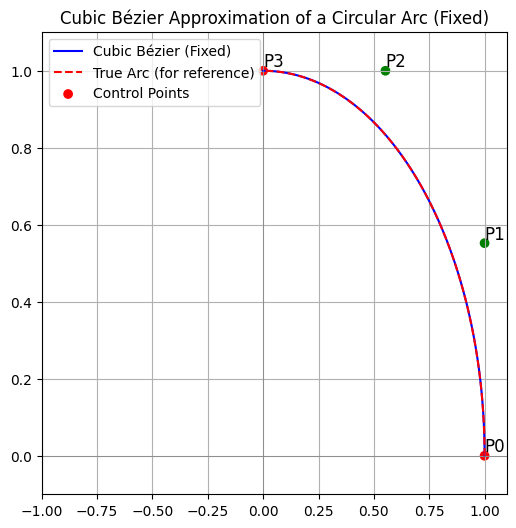

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def bezier_curve(t, P0, P1, P2, P3):
    """ Cubic Bézier 곡선 공식 """
    return ( (1-t)**3 * np.array(P0) +
             3*(1-t)**2 * t * np.array(P1) +
             3*(1-t) * t**2 * np.array(P2) +
             t**3 * np.array(P3) )

# 반지름
r = 1
k = (4/3) * np.tan(np.pi / 8)  # k 값 제대로 설정

# 올바른 Bézier 컨트롤 포인트
P0 = (r, 0)          # 시작점
P1 = (r, k*r)        # 컨트롤 포인트 1 (위로 이동)
P2 = (k*r, r)        # 컨트롤 포인트 2 (오른쪽 이동)
P3 = (0, r)          # 끝점

# Bézier 곡선 좌표 계산
t_values = np.linspace(0, 1, 100)
bezier_points = np.array([bezier_curve(t, P0, P1, P2, P3) for t in t_values])

# 원호(정확한 원 비교용)
theta = np.linspace(0, np.pi/2, 100)
arc_x = r * np.cos(theta)
arc_y = r * np.sin(theta)

# 그래프 출력
plt.figure(figsize=(6,6))
plt.plot(bezier_points[:,0], bezier_points[:,1], 'b-', label="Cubic Bézier (Fixed)")
plt.plot(arc_x, arc_y, 'r--', label="True Arc (for reference)")
plt.scatter(*zip(P0, P1, P2, P3), color=['red', 'green', 'green', 'red'], label="Control Points")
plt.text(P0[0], P0[1], "P0", fontsize=12, verticalalignment='bottom')
plt.text(P1[0], P1[1], "P1", fontsize=12, verticalalignment='bottom')
plt.text(P2[0], P2[1], "P2", fontsize=12, verticalalignment='bottom')
plt.text(P3[0], P3[1], "P3", fontsize=12, verticalalignment='bottom')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlim(-r, r*1.1)
plt.ylim(-r*0.1, r*1.1)
plt.legend()
plt.grid()
plt.title("Cubic Bézier Approximation of a Circular Arc (Fixed)")
plt.show()